# Chapter 4: The Smoother
Brown's practical question is how quickly a forecast should forget. These seeded
synthetic monthly series let us see the responsiveness/noise trade-off directly.
We implement SES, Holt, damped Holt, seasonal Holt-Winters and a Theta benchmark.
Figures belong to **The Methods**. Data are illustrative, not Navy records.

In [1]:
from pathlib import Path
import sys
project = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0, str(project/'companion/src'))
from forecasting_companion.common import *
import pandas as pd
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel
rng = begin(4)

## How much of today's surprise becomes tomorrow's level?
SES updates level as alpha × observation + (1-alpha) × previous level.
The lines below are updated levels, not forecasts made before seeing that point.

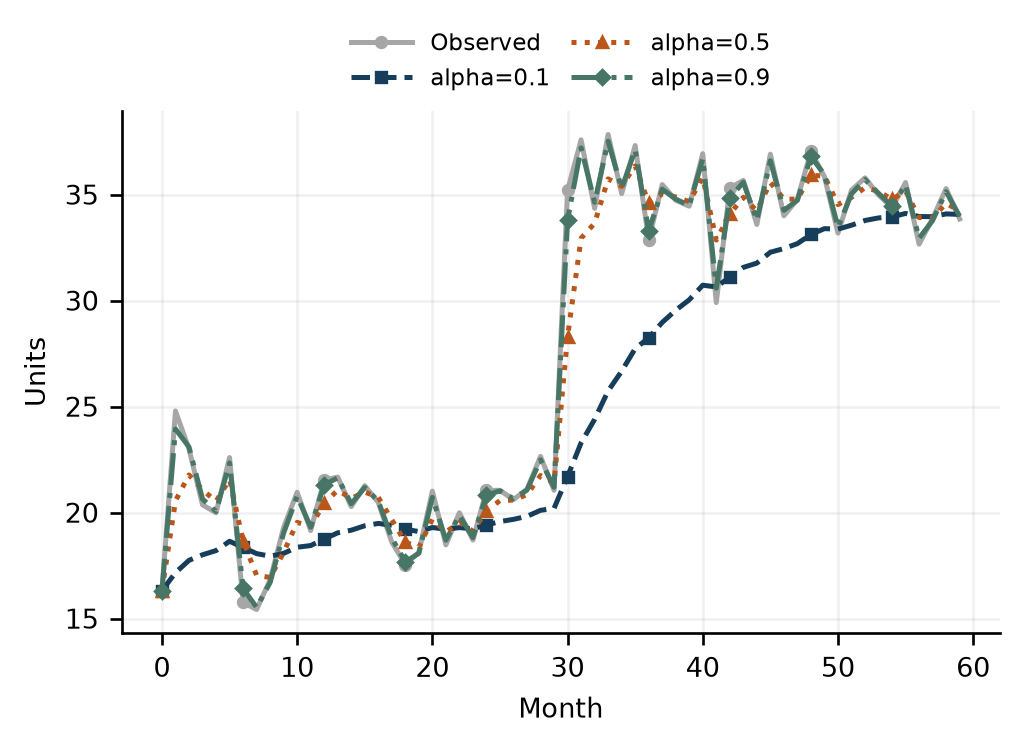

In [2]:
y = np.r_[np.repeat(20.,30), np.repeat(35.,30)] + rng.normal(0,2,60)
plt.figure(); plt.plot(y, color='.65', label='Observed')
for alpha in [.1,.5,.9]:
    levels = [y[0]]
    for value in y[1:]: levels.append(alpha*value+(1-alpha)*levels[-1])
    plt.plot(levels, label=f'alpha={alpha}')
plt.xlabel('Month'); plt.ylabel('Units'); plt.legend(fontsize=7)
save(4,1,'How fast should a forecast forget?', 'Synthetic level shift. Faster updates react sooner but follow more observation noise.', '## The Methods')

## A trend need not continue forever
Fit both models on the same observations. Damping makes each additional trend
increment smaller; it does not guarantee that the forecast is more accurate.

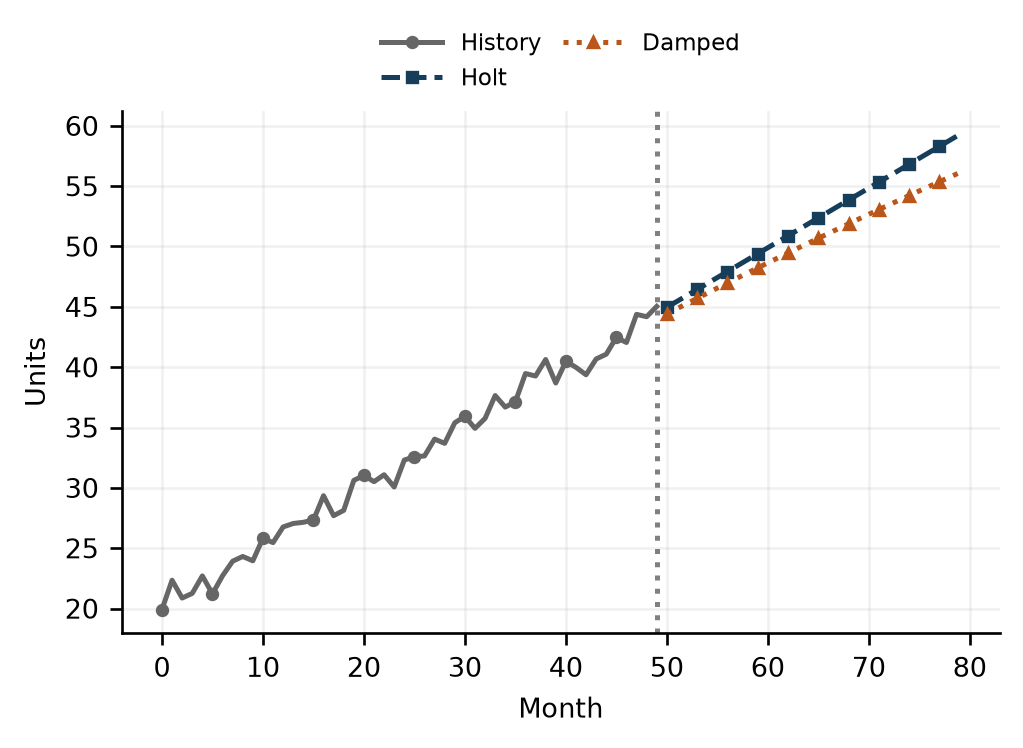

In [3]:
trend = 20 + .5*np.arange(50) + rng.normal(0,1,50)
plt.figure(); plt.plot(trend, label='History', color='.4')
for damping in [False,True]:
    fit = Holt(trend, damped_trend=damping, initialization_method='estimated').fit()
    plt.plot(np.arange(50,80),fit.forecast(30),label='Damped' if damping else 'Holt')
plt.axvline(49,color='.5',ls=':'); plt.xlabel('Month'); plt.ylabel('Units'); plt.legend()
save(4,2,'Damping the distant trend','Synthetic trend. The undamped forecast extrapolates its final slope; the damped model progressively reduces it.','## The Methods')

## Compare on future observations
The last two years are untouched holdout data. No method selection is made on
this holdout. We report MAE even when a more complex method fails to win.

Seasonal naive    2.88
SES               7.16
Holt-Winters      1.64
Theta             1.82


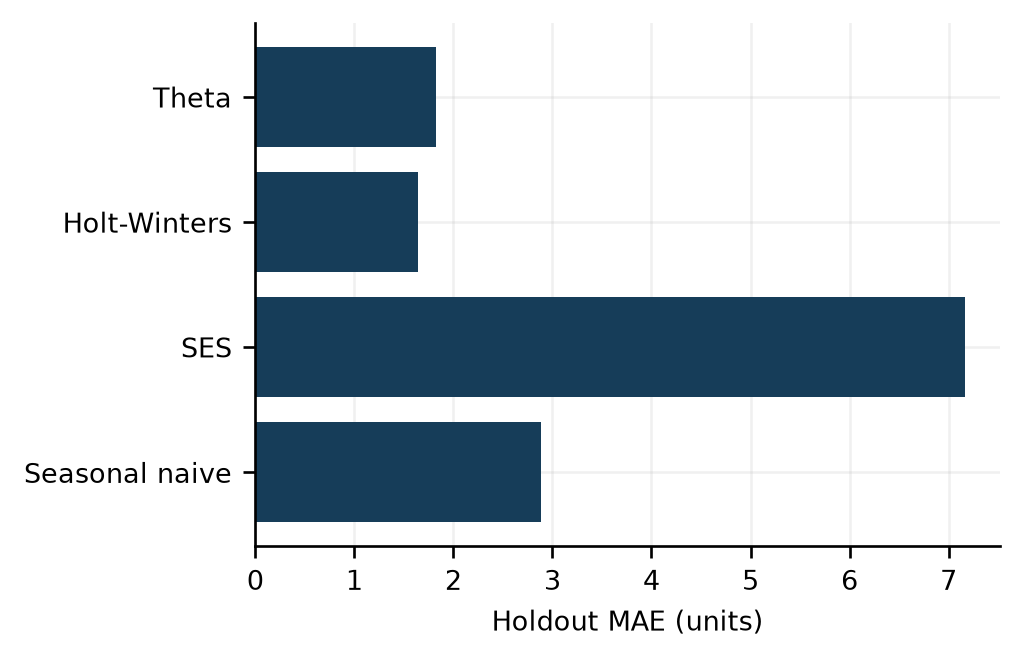

In [4]:
y = seasonal_series(rng); train, test = y[:-24], y[-24:]
forecasts = {'Seasonal naive':np.tile(train[-12:],2),
    'SES':SimpleExpSmoothing(train,initialization_method='estimated').fit().forecast(24),
    'Holt-Winters':ExponentialSmoothing(train,trend='add',seasonal='add',seasonal_periods=12).fit().forecast(24),
    'Theta':ThetaModel(train,period=12).fit().forecast(24)}
errors = {k:mae(test,v) for k,v in forecasts.items()}
print(pd.Series(errors,name='holdout MAE (24 months)').round(2).to_string())
assert all(np.isfinite(list(errors.values())))
plt.figure(); plt.barh(list(errors),list(errors.values())); plt.xlabel('Holdout MAE (units)')
save(4,3,'Seasonality earns its place on the holdout','Synthetic monthly demand; errors are computed on 24 unseen months. Seasonal-naive is the reference.','## The Methods')

## Limits and exercise
These models assume patterns persist. Add a level break during the holdout and
rerun: which methods fail, and why? Multiplicative seasonality needs positive
observations. Box-Cox inverse transforms require a mean/median distinction.
TBATS and complex exponential smoothing are advanced extensions, not executed
here. API reference: https://www.statsmodels.org/dev/examples/notebooks/generated/exponential_smoothing.html

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV: timestamp (unique ISO period), target (finite number in consistent units). Config: frequency, horizon, season, as_of, units and source. At least two complete seasonal cycles are needed even to attempt seasonal estimation; reserve further data for evaluation. The rolling comparison needs 2 seasons + 4 horizons of history (72 monthly points for a 12-month horizon, 48 for six months, 36 for three); with less, the tool returns a provisional persistence baseline and says how many points are missing. Zero sales are observations; absent months are missing.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
2024-01-01,100
2024-02-01,110
2024-03-01,105
```

## Explain the mechanism

SES carries one level forward. Holt carries level and slope; damping reduces future slope increments. Holt-Winters adds a repeating seasonal component. These are alternative assumptions about what persists. Choose the memory length by future forecast loss, not by how closely the fitted line hugs history.

## Work through the arithmetic

With previous level 100, observation 120 and alpha=.25, the updated level is .25×120+.75×100=105. That is the next one-step SES forecast, not the forecast that existed before observing 120. With Holt level 105 and slope 4, a three-step forecast is 117. With damping phi=.8 it is 105+4(.8+.64+.512)=112.808.

## Adapt the lesson to reader data

Replace the lesson’s generated y in the level experiment or final seasonal experiment with one regularly indexed observed timestamp,target series, keeping the experiments separate. The small CSV above illustrates syntax only: it is not enough to fit annual seasonality. Set period=12 for monthly annual seasonality only when the calendar and history justify it. The applied adapter now performs the common expanding-origin comparison. Inspect summary.json validation rows and test_mae separately; no additional loop is needed for that supplied comparison.

For this chapter, settle these questions before fitting: What is the observation frequency and decision horizon? Is demand censored by stockouts? Which seasonal period is plausible? Is the business changing enough that old cycles are misleading?

## Interpret the actual lesson outputs

The level-shift curves are updated levels after observing each point. They demonstrate responsiveness, not pre-observation accuracy. The final holdout MAE chart compares only its named methods and uses a favorable seasonal generator. A lower bar supports that method on that holdout. It does not establish a universal ranking. The applied adapter adds a common rolling comparison; inspect its separate validation table rather than attributing that work to the original holdout chart.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,forecast,model,empirical_q10,empirical_q50,empirical_q90,lower,upper,interval_level`.
- `summary.json`: `pool,selected,transform,specification,origins,horizon,season,leaderboard,validation,validation_predictions,test_mae,test_interval_coverage,skipped,executed,evaluation,intervals` plus method, interpretation, assumptions, not_done and status.

The adapter runs the companion engine with the `smoothing` pool: naive, seasonal naive, drift, SES, Holt, damped Holt, an AICc-selected ETS form (additive or multiplicative error and seasonality, damped or not), Theta and STL+ETS. A log transform is chosen on training data when positive values and a Box-Cox lambda near zero call for it (`transform: auto|none|log`). Up to five expanding origins (`origins`) select the model on MAE; a final untouched holdout scores it once; the selection is refitted on all history. Output carries the model's nominal 80% interval with its measured validation coverage, plus empirical residual quantiles by horizon step. Optional `pool` overrides the method set. A short but valid regular series returns status=provisional with naive and, when available, seasonal-naive scenario values rather than pretending a model was validated.

## Decide what the evidence supports

Inspect seasonal residual patterns, residual bias and parameter estimates at boundaries. A low fitted SSE is not selection evidence. Never force multiplicative seasonality onto zeros or negative values. Long trends need a damping sensitivity. Backtested marginal coverage is evidence for the tested horizons, not a guarantee after a break.

With one seasonal cycle, use naive or a defensible seasonal-naive comparison and mark seasonality estimation unsupported. For gaps, report the cause and perform training-only imputation or shorten the usable series; do not turn unknown sales into zeros. Without evaluation history, supply an explicitly provisional forecast and scenarios.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,forecast,model,empirical_q10,empirical_q50,empirical_q90,lower,upper,interval_level`; `summary.json` keys: `pool,selected,transform,specification,origins,horizon,season,leaderboard,validation,validation_predictions,test_mae,test_interval_coverage,skipped,executed,evaluation,intervals` plus method, interpretation, assumptions, not_done and status. Report the measured coverage of lower/upper at the selection origins beside the nominal level; never quote the nominal level alone. Also return a per-origin MAE table, skipped-method reasons, seasonal assumptions and whether uncertainty was calibrated or only scenarized.

## Three exercises with worked solutions

### Exercise 1

Recalculate the SES update with alpha=.8. What changes?

**Worked solution.** The level is 116. It reacts more quickly to the shock, but this calculation alone says nothing about future accuracy.

### Exercise 2

Actuals are 100,120 and forecasts A=110,110, B=100,100. Compare MAE.

**Worked solution.** A has MAE (10+10)/2=10; B has (0+20)/2=10. Prefer neither on this score alone; examine the decision costs and further origins.

### Exercise 3

You receive eighteen monthly observations with three unknown months. May you report annual Holt-Winters as validated?

**Worked solution.** No. There are not two complete annual cycles, much less a separate evaluation period. Audit missingness, use an eligible simple baseline and disclose the unsupported seasonal fit.

## Business-reader application

Use this request with the skill:

> Apply chapter 4 to monthly demand.csv for the next six months. Audit gaps and stockouts, compare supported smoothing methods at earlier six-month origins, retain a final holdout, and return the forecast plus a defensible uncertainty statement.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch04-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 4 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch04-observed.json \
  --output companion/applied-runs/ch04-observed-reader
```

Compare the two validation origins with final-test MAE. Does the selected smoothing method still beat seasonal-naive on the last twelve months? Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch04.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch04.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(4, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch04-workshop-results.csv', index=False)
_ = (workshop_output/'ch04-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Rolling-origin model comparison with final holdout
Status: passed

Interpretation: ETS(auto) had the lowest mean validation MAE (1.86); the runner-up was Theta (1.97). Final-holdout MAE for the selection: 1.67. Compare against Seasonal naive before trusting the gain.

Assumptions:
  - Regular series with the declared season and no missing periods
  - The training history's pattern continues over the horizon (no regime change)
  - Specifications are frozen on the first training slice, so later actuals cannot steer selection
Not done:
  - No regressors, promotions or calendar effects (chapter 13 or 16 add them)
  - No hierarchy or coherence constraints (chapter 18)
  - Intervals are the selected model's own plus empirical residual quantiles; no distribution-free guarantee (chapter 17)

Evidence:
  pool: smoothing
  selected: ETS(auto)
  transform: none
  specification: <3 entries>
  origins: [2015-12-01 00:00:00+00:00, 2016-12-01 00:00:00+00:00, 2017-12-01 00:00:00+00:00, 2018-12

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [6]:
observed_input = pd.read_csv(project_path/'companion/data/observed/monthly-temperature.csv')
observed_config = json.loads((project_path/'companion/configs/ch04-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(4, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch04-observed-results.csv', index=False)
_ = (workshop_output/'ch04-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
Method: Rolling-origin model comparison with final holdout
Status: passed

Interpretation: Seasonal naive had the lowest mean validation MAE (1.1); the runner-up was ETS(auto) (1.44). Final-holdout MAE for the selection: 1.21. Compare against Seasonal naive before trusting the gain.

Assumptions:
  - Regular series with the declared season and no missing periods
  - The training history's pattern continues over the horizon (no regime change)
  - Specifications are frozen on the first training slice, so later actuals cannot steer selection
Not done:
  - No regressors, promotions or calendar effects (chapter 13 or 16 add them)
  - No hierarchy or coherence constraints (chapter 18)
  - Intervals are the selected model's own plus empirical residual quantiles; no distribution-free guarantee (chapter 17)

Evidence:
  pool: smoothing
  selected: Seasonal naive
  transform: log
  specif